# STEP 1 — Install and import libraries

In [ ]:
import numpy as np
import random
import imageio
from scipy import stats
import matplotlib.pyplot as plt
import os


# STEP 2 — Download ORL dataset


In [ ]:
# download and unzip ORL faces
!wget -q http://www.cl.cam.ac.uk/research/dtg/attarchive/pub/data/att_faces.zip -O att_faces.zip
!unzip -q -o att_faces.zip -d /content/att_faces
!ls -la /content/att_faces


total 172
drwxr-xr-x 42 root root 4096 Nov 10 17:47 .
drwxr-xr-x  1 root root 4096 Nov 10 17:47 ..
-rw-rw-rw-  1 root root 1579 Feb 23  1995 README
drwxrwxrwx  2 root root 4096 Apr 18  1994 s1
drwxrwxrwx  2 root root 4096 Apr 18  1994 s10
drwxrwxrwx  2 root root 4096 Apr 18  1994 s11
drwxrwxrwx  2 root root 4096 Apr 18  1994 s12
drwxrwxrwx  2 root root 4096 Apr 18  1994 s13
drwxrwxrwx  2 root root 4096 Apr 18  1994 s14
drwxrwxrwx  2 root root 4096 Apr 18  1994 s15
drwxrwxrwx  2 root root 4096 Apr 18  1994 s16
drwxrwxrwx  2 root root 4096 Apr 18  1994 s17
drwxrwxrwx  2 root root 4096 Apr 18  1994 s18
drwxrwxrwx  2 root root 4096 Apr 18  1994 s19
drwxrwxrwx  2 root root 4096 Apr 18  1994 s2
drwxrwxrwx  2 root root 4096 Apr 18  1994 s20
drwxrwxrwx  2 root root 4096 Apr 18  1994 s21
drwxrwxrwx  2 root root 4096 Apr 18  1994 s22
drwxrwxrwx  2 root root 4096 Apr 18  1994 s23
drwxrwxrwx  2 root root 4096 Apr 18  1994 s24
drwxrwxrwx  2 root root 4096 Apr 18  1994 s25
drwxrwxrwx  2 root root 40

# STEP 3 — Load & preprocess images into a data matrix

Loaded 400 images, vector size m=4096 (image size (64, 64))


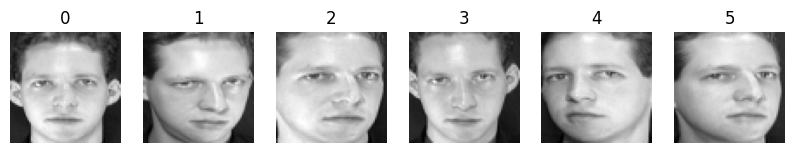

In [ ]:
import cv2

# STEP 3: loader + preprocessing
DATA_FOLDER = '/content/att_faces'   # change if you uploaded elsewhere
IMG_SIZE = (64, 64)  # (W,H)

def load_images_from_orl(folder=DATA_FOLDER, size=IMG_SIZE, max_persons=None):
    imgs, paths = [], []
    persons = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder,d))])
    if max_persons:
        persons = persons[:max_persons]
    for p in persons:
        person_dir = os.path.join(folder, p)
        for fname in sorted(os.listdir(person_dir)):
            if fname.lower().endswith(('.pgm','.png','.jpg','.jpeg')):
                path = os.path.join(person_dir, fname)
                im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                im = cv2.resize(im, size, interpolation=cv2.INTER_AREA)
                imgs.append(im.astype(np.float32))
                paths.append(path)
    X = np.column_stack([im.flatten() for im in imgs])  # m x n
    return X, imgs, paths

X, images, paths = load_images_from_orl()
m, n = X.shape
print(f"Loaded {n} images, vector size m={m} (image size {IMG_SIZE})")

# show first 6 images as sanity
plt.figure(figsize=(10,4))
for i in range(min(6, len(images))):
    plt.subplot(1,6,i+1)
    plt.imshow(images[i].astype(np.uint8), cmap='gray'); plt.axis('off'); plt.title(i)
plt.show()


# STEP 4 — Compute PCA via SVD and show mean + top eigenfaces

Shapes: mean: (4096, 1) U_full: (4096, 400) S_full: (400,) Vt: (400, 400)


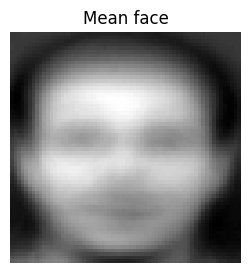

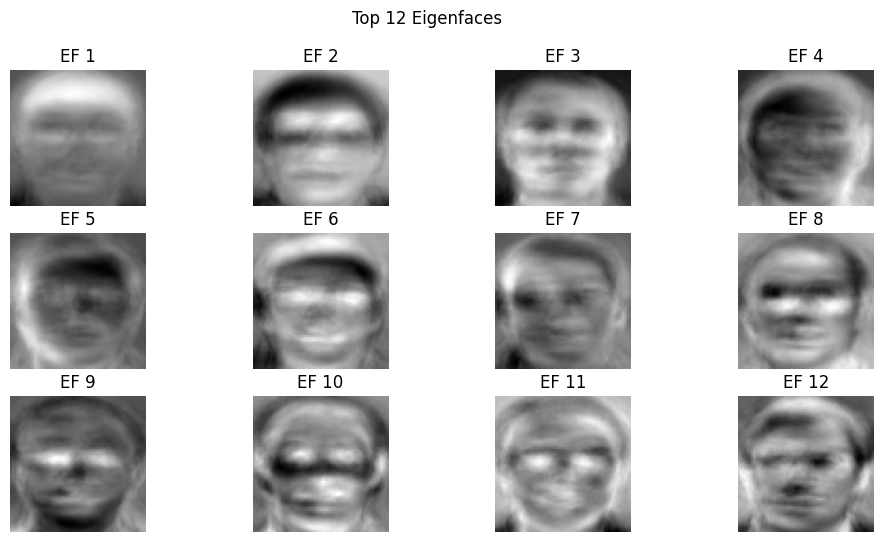

In [ ]:
# STEP 4: compute full SVD (mean-centered) and show eigenfaces
mean_full = X.mean(axis=1, keepdims=True)   # m x 1
Xc_full = X - mean_full
U_full, S_full, Vt_full = np.linalg.svd(Xc_full, full_matrices=False)
print("Shapes: mean:", mean_full.shape, "U_full:", U_full.shape, "S_full:", S_full.shape, "Vt:", Vt_full.shape)

# show mean face
mean_img = mean_full.ravel().reshape(IMG_SIZE)
plt.figure(figsize=(3,3)); plt.imshow(mean_img.astype(np.uint8), cmap='gray'); plt.title('Mean face'); plt.axis('off'); plt.show()

# show top 12 eigenfaces
plt.figure(figsize=(12,6))
for i in range(12):
    ef = U_full[:, i].reshape(IMG_SIZE)
    ef_vis = 255 * (ef - ef.min())/(ef.max()-ef.min()+1e-12)
    plt.subplot(3,4,i+1); plt.imshow(ef_vis.astype(np.uint8), cmap='gray'); plt.axis('off'); plt.title(f"EF {i+1}")
plt.suptitle("Top 12 Eigenfaces"); plt.show()

# STEP 5 — Project two faces, interpolate, reconstruct, save GIF

0 /content/att_faces/s1/1.pgm
1 /content/att_faces/s1/10.pgm
2 /content/att_faces/s1/2.pgm
3 /content/att_faces/s1/3.pgm
4 /content/att_faces/s1/4.pgm
5 /content/att_faces/s1/5.pgm
6 /content/att_faces/s1/6.pgm
7 /content/att_faces/s1/7.pgm
8 /content/att_faces/s1/8.pgm
9 /content/att_faces/s1/9.pgm
10 /content/att_faces/s10/1.pgm
11 /content/att_faces/s10/10.pgm
12 /content/att_faces/s10/2.pgm
13 /content/att_faces/s10/3.pgm
14 /content/att_faces/s10/4.pgm
15 /content/att_faces/s10/5.pgm
16 /content/att_faces/s10/6.pgm
17 /content/att_faces/s10/7.pgm
18 /content/att_faces/s10/8.pgm
19 /content/att_faces/s10/9.pgm
20 /content/att_faces/s11/1.pgm
21 /content/att_faces/s11/10.pgm
22 /content/att_faces/s11/2.pgm
23 /content/att_faces/s11/3.pgm
24 /content/att_faces/s11/4.pgm
25 /content/att_faces/s11/5.pgm
26 /content/att_faces/s11/6.pgm
27 /content/att_faces/s11/7.pgm
28 /content/att_faces/s11/8.pgm
29 /content/att_faces/s11/9.pgm


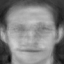

Saved morph_basic.gif for indices 0->5 using k=50


In [ ]:
from IPython.display import Image, display


# STEP 5: helper project/reconstruct and single morph example (same flow)
def project(vec, mean, U_k):
    return U_k.T.dot(vec - mean.ravel())

def reconstruct(z, mean, U_k):
    xhat = U_k.dot(z) + mean.ravel()
    return xhat

# pick two sample indices (print first 30 to choose)
for i,p in enumerate(paths[:30]):
    print(i, p)
# default pick (you can edit)
idxA, idxB = 0, 5

k = 50  # initial k (you'll find optimal later)
U_k = U_full[:, :k]

vecA = X[:, idxA]
vecB = X[:, idxB]
zA = project(vecA, mean_full, U_k)
zB = project(vecB, mean_full, U_k)

steps = 30
frames = []
for t in np.linspace(0,1,steps):
    zt = (1-t)*zA + t*zB
    xhat = reconstruct(zt, mean_full, U_k)
    frame = np.clip(xhat.reshape(IMG_SIZE), 0, 255).astype(np.uint8)
    frames.append(frame)

out_gif = 'morph_basic.gif'
imageio.mimsave(out_gif, frames, duration=0.08)
display(Image(out_gif))
print("Saved", out_gif, f"for indices {idxA}->{idxB} using k={k}")


# STEP 6 — Add optimization & stats helpers (reconstruction MSE, smoothness, probabilistic morph)

In [ ]:
# STEP 6: helpers for MSE, smoothness, probabilistic morphs
def mse_image(a, b):
    return np.mean((a.ravel().astype(np.float32) - b.ravel().astype(np.float32))**2)

def compute_reconstruction_mse_all(X, mean, U_k):
    n = X.shape[1]
    mses = []
    for i in range(n):
        vec = X[:, i]
        z = U_k.T.dot(vec - mean.ravel())
        xhat = U_k.dot(z) + mean.ravel()
        mses.append(mse_image(vec, xhat))
    return float(np.mean(mses)), np.array(mses)

def morph_frames_linear(zA, zB, mean, U_k, steps=30):
    frames = []
    for t in np.linspace(0, 1, steps):
        zt = (1-t)*zA + t*zB
        xhat = U_k.dot(zt) + mean.ravel()
        frames.append(np.clip(xhat, 0, 255).astype(np.float32))
    return frames

def smoothness_of_frames(frames):
    diffs = []
    for i in range(len(frames)-1):
        diffs.append(mse_image(frames[i], frames[i+1]))
    return float(np.mean(diffs)), np.array(diffs)

def coeff_stats(X, mean, U_k):
    Z = U_k.T.dot(X - mean)  # k x n
    mean_z = np.mean(Z, axis=1)
    cov_z = np.cov(Z)
    return mean_z, cov_z

def morph_frames_probabilistic_adaptive(zA, zB, mean, U_k, cov_z, steps=30, noise_scale=0.05, seed=None):
    if seed is not None:
        np.random.seed(seed)

    frames = []
    L = np.linalg.cholesky(cov_z + 1e-6 * np.eye(cov_z.shape[0]))  # stable
    for i, t in enumerate(np.linspace(0, 1, steps)):
        # Interpolation
        zt = (1 - t) * zA + t * zB

        # Adaptive noise factor: max in middle, near zero at ends
        noise_factor = np.exp(-((t - 0.5) ** 2) / (2 * (0.25 ** 2)))
        noise_factor /= noise_factor.max()  # normalize to [0,1]

        # Add scaled noise
        noise = L @ np.random.randn(len(zA))
        zt_noisy = zt + noise_scale * noise_factor * noise

        # Reconstruct
        xhat = U_k @ zt_noisy + mean.ravel()
        frame = np.clip(xhat, 0, 255).astype(np.uint8)
        frames.append(frame)
    return frames


# STEP 7 — Grid search to pick k (balance recon MSE vs morph smoothness)

In [ ]:
# STEP 7: evaluate k grid (quick grid search)
def evaluate_k_grid(X, mean_full, U_full, k_values, num_pairs=6, steps=20, alpha=0.5, seed=42):
    random.seed(seed)
    results = []
    recon_mses = []
    smooth_vals = []
    for k in k_values:
        U_k = U_full[:, :k]
        recon_mean_mse, _ = compute_reconstruction_mse_all(X, mean_full, U_k)
        smoothness_list = []
        for _ in range(num_pairs):
            ia, ib = random.sample(range(X.shape[1]), 2)
            zA = U_k.T.dot(X[:, ia] - mean_full.ravel())
            zB = U_k.T.dot(X[:, ib] - mean_full.ravel())
            frames = morph_frames_linear(zA, zB, mean_full, U_k, steps=steps)
            smooth_mean, _ = smoothness_of_frames(frames)
            smoothness_list.append(smooth_mean)
        avg_smooth = float(np.mean(smoothness_list))
        recon_mses.append(recon_mean_mse)
        smooth_vals.append(avg_smooth)
        results.append({'k':k, 'recon_mse':recon_mean_mse, 'avg_smooth':avg_smooth})
        print(f"k={k}: recon_mse={recon_mean_mse:.3f}, avg_smooth={avg_smooth:.5f}")
    recon_arr = np.array(recon_mses); smooth_arr = np.array(smooth_vals)
    rmax, smax = recon_arr.max(), smooth_arr.max()
    for r in results:
        rn = r['recon_mse']/(rmax + 1e-12)
        sn = r['avg_smooth']/(smax + 1e-12)
        r['J'] = alpha*rn + (1-alpha)*sn
    results_sorted = sorted(results, key=lambda x: x['J'])
    return results_sorted, recon_arr, smooth_arr

# run a small grid (adjust as needed)
k_values = [5, 10, 20, 30, 40, 60]   # small for demo
results_sorted, recon_arr, smooth_arr = evaluate_k_grid(X, mean_full, U_full, k_values,
                                                        num_pairs=6, steps=20, alpha=0.5)
print("\nTop choices by objective J:")
for r in results_sorted[:5]:
    print(r)

k=5: recon_mse=712.278, avg_smooth=4.15839
k=10: recon_mse=530.634, avg_smooth=4.83507
k=20: recon_mse=379.698, avg_smooth=6.79192
k=30: recon_mse=301.722, avg_smooth=5.13120
k=40: recon_mse=249.834, avg_smooth=5.40135
k=60: recon_mse=183.768, avg_smooth=6.61672

Top choices by objective J:
{'k': 40, 'recon_mse': 249.83370971679688, 'avg_smooth': 5.401348829269409, 'J': np.float64(0.5730067835592808)}
{'k': 30, 'recon_mse': 301.7216796875, 'avg_smooth': 5.131197492281596, 'J': np.float64(0.5895430462562151)}
{'k': 60, 'recon_mse': 183.7683563232422, 'avg_smooth': 6.616719643274943, 'J': np.float64(0.61610245883722)}
{'k': 10, 'recon_mse': 530.6343383789062, 'avg_smooth': 4.835066417853038, 'J': np.float64(0.7284333092317233)}
{'k': 20, 'recon_mse': 379.697509765625, 'avg_smooth': 6.791923562685649, 'J': np.float64(0.7665373889295415)}


# STEP 8 — Choose k and compute PCA stats (k chosen)

In [ ]:
# STEP 8: pick k (from grid output)
k_chosen = results_sorted[0]['k']  # default: top ranked k
print("Chosen k:", k_chosen)
U_k = U_full[:, :k_chosen]
mean = mean_full

# compute PCA coefficient covariance for probabilistic morph
mean_z, cov_z = coeff_stats(X, mean, U_k)
print("mean_z shape:", mean_z.shape, "cov_z shape:", cov_z.shape)

Chosen k: 40
mean_z shape: (40,) cov_z shape: (40, 40)


# STEP 9 — Compare linear vs probabilistic morphs statistically

In [ ]:
# STEP 9: compare linear vs probabilistic morphs (paired t-test)
import numpy as np

def morph_frames_probabilistic(zA, zB, mean, U_k, cov_z, steps=30, noise_scale=0.03, seed=0):
    np.random.seed(seed)
    frames = []
    for t in np.linspace(0, 1, steps):
        # Linear interpolation of latent vectors
        z_t = (1 - t) * zA + t * zB

        # Add Gaussian noise for probabilistic variation
        noise = np.random.multivariate_normal(np.zeros_like(z_t), cov_z) * noise_scale
        z_t_noisy = z_t + noise

        # Reconstruct frame from PCA space
        x_t = U_k @ z_t_noisy + mean.ravel()
        frames.append(x_t)
    return np.array(frames)

def compare_linear_vs_prob(X, mean, U_k, cov_z, num_pairs=10, steps=30, noise_scale=0.03, samples_per_pair=1, seed=0):
    rng = random.Random(seed)
    linear_smoothness = []
    prob_smoothness = []
    for _ in range(num_pairs):
        ia, ib = rng.sample(range(X.shape[1]), 2)
        zA = U_k.T.dot(X[:, ia] - mean.ravel())
        zB = U_k.T.dot(X[:, ib] - mean.ravel())
        frames_lin = morph_frames_linear(zA, zB, mean, U_k, steps=steps)
        s_lin, _ = smoothness_of_frames(frames_lin)
        linear_smoothness.append(s_lin)
        s_probs = []
        for s in range(samples_per_pair):
            frames_prob = morph_frames_probabilistic(zA, zB, mean, U_k, cov_z, steps=steps,
                                                     noise_scale=noise_scale, seed=seed+s)
            s_p, _ = smoothness_of_frames(frames_prob)
            s_probs.append(s_p)
        prob_smoothness.append(float(np.mean(s_probs)))
    tstat, pval = stats.ttest_rel(linear_smoothness, prob_smoothness)
    mean_diff = np.mean(np.array(linear_smoothness) - np.array(prob_smoothness))
    return {'linear': linear_smoothness, 'prob': prob_smoothness, 'tstat': float(tstat), 'pval': float(pval), 'mean_diff': float(mean_diff)}

res = compare_linear_vs_prob(X, mean, U_k, cov_z, num_pairs=8, steps=30, noise_scale=0.03, samples_per_pair=2, seed=1)
print("Paired t-test linear vs probabilistic morphs")
print("t-stat:", res['tstat'], "p-val:", res['pval'], "mean_diff (linear - prob):", res['mean_diff'])
print("Linear smoothness list:", np.round(res['linear'],4))
print("Prob  smoothness list:", np.round(res['prob'],4))


Paired t-test linear vs probabilistic morphs
t-stat: -205.79576157559134 p-val: 1.6884838772880902e-14 mean_diff (linear - prob): -2.245070517063141
Linear smoothness list: [1.5728 2.6598 1.8527 3.5741 2.6674 2.3687 2.2179 1.8123]
Prob  smoothness list: [3.8221 4.9304 4.1017 5.7575 4.956  4.6047 4.4691 4.0447]


# STEP 10 — Visual comparison: save example linear vs probabilistic GIFs

Example indices: 116 395 paths: /content/att_faces/s2/6.pgm /content/att_faces/s9/5.pgm
Saved morph_linear_example.gif and morph_prob_example.gif


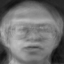

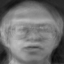

In [ ]:
# STEP 10: example visual comparison
ia, ib = random.sample(range(X.shape[1]), 2)
print("Example indices:", ia, ib, "paths:", paths[ia], paths[ib])

zA = U_k.T.dot(X[:, ia] - mean.ravel())
zB = U_k.T.dot(X[:, ib] - mean.ravel())

frames_lin = morph_frames_linear(zA, zB, mean, U_k, steps=30)
frames_prob = morph_frames_probabilistic(zA, zB, mean, U_k, cov_z, steps=30, noise_scale=0.03, seed=5)

imageio.mimsave('morph_linear_example.gif', [f.reshape(IMG_SIZE) for f in frames_lin], duration=0.08)
imageio.mimsave('morph_prob_example.gif', [f.reshape(IMG_SIZE) for f in frames_prob], duration=0.08)
print("Saved morph_linear_example.gif and morph_prob_example.gif")
display(Image('morph_linear_example.gif'))
display(Image('morph_prob_example.gif'))


In [ ]:
# STEP 11: Auto-generate multiple example pairs (linear + probabilistic)
import random

num_examples = 4
frames_naive_all = []
frames_opt_all = []

for i in range(num_examples):
    ia, ib = random.sample(range(X.shape[1]), 2)

    # Project into eigen-space
    zA = U_k.T.dot(X[:, ia] - mean.ravel())
    zB = U_k.T.dot(X[:, ib] - mean.ravel())

    # Naive (linear) morph
    frames_lin = morph_frames_linear(zA, zB, mean, U_k, steps=30)
    frames_naive_all.append(frames_lin)

    # Probabilistic morph (optimization-inspired)
    frames_prob = morph_frames_probabilistic(
        zA, zB, mean, U_k, cov_z,
        steps=30, noise_scale=0.03, seed=i+10
    )
    frames_opt_all.append(frames_prob)

    # Save GIFs
    gif1 = f'morph_naive_{ia}_{ib}.gif'
    gif2 = f'morph_opt_{ia}_{ib}.gif'
    imageio.mimsave(gif1, [f.reshape(IMG_SIZE) for f in frames_lin], duration=0.08)
    imageio.mimsave(gif2, [f.reshape(IMG_SIZE) for f in frames_prob], duration=0.08)

    print(f"Saved {gif1} and {gif2} for pair {ia} -> {ib}")

print(f"\nStored {len(frames_naive_all)} naive morph sequences and {len(frames_opt_all)} optimized morph sequences for metrics.")


Saved morph_naive_148_40.gif and morph_opt_148_40.gif for pair 148 -> 40
Saved morph_naive_119_51.gif and morph_opt_119_51.gif for pair 119 -> 51
Saved morph_naive_194_142.gif and morph_opt_194_142.gif for pair 194 -> 142
Saved morph_naive_232_325.gif and morph_opt_232_325.gif for pair 232 -> 325

Stored 4 naive morph sequences and 4 optimized morph sequences for metrics.


                          Method  MSE_Reconstruction  Smoothness_Variance  \
0                Naive PCA Morph          249.833701         5.916735e-07   
1  Optimized Probabilistic Morph          249.833701         5.143803e+00   

   Avg_Sharpness  Avg_SSIM  
0      59.113819  0.910325  
1      59.344932  0.908346  


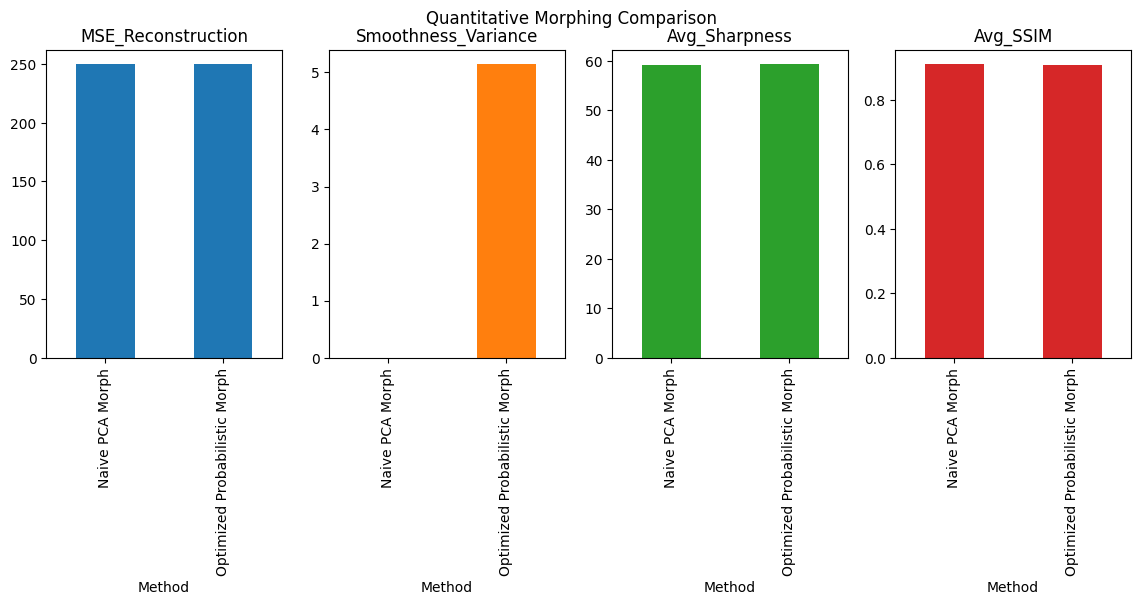

In [ ]:
import numpy as np
import pandas as pd
from skimage.metrics import mean_squared_error as mse, structural_similarity as ssim
from scipy.ndimage import laplace
import matplotlib.pyplot as plt

# --- Metric functions ---
def mse_reconstruction(X, mean, U_k):
    total = 0
    for i in range(X.shape[1]):
        z = U_k.T @ (X[:, i] - mean.ravel())
        xhat = U_k @ z + mean.ravel()
        total += mse(X[:, i], xhat)
    return total / X.shape[1]

def morph_smoothness(frames):
    # Smoothness = variance of pixel differences between consecutive frames
    diffs = [np.mean((frames[i+1] - frames[i])**2) for i in range(len(frames)-1)]
    return np.var(diffs)

def avg_sharpness(frames):
    # Sharpness via Laplacian energy
    return np.mean([np.var(laplace(f)) for f in frames])

def avg_ssim(frames, imgA, imgB):
    # Compare each frame to both start/end faces, take the max SSIM
    ssim_scores = []
    for f in frames:
        s1 = ssim(f, imgA, data_range=f.max() - f.min())
        s2 = ssim(f, imgB, data_range=f.max() - f.min())
        ssim_scores.append(max(s1, s2))
    return np.mean(ssim_scores)

# --- Build results table ---
results = {
    "Method": [],
    "MSE_Reconstruction": [],
    "Smoothness_Variance": [],
    "Avg_Sharpness": [],
    "Avg_SSIM": []
}

# --- Naive ---
results["Method"].append("Naive PCA Morph")
results["MSE_Reconstruction"].append(mse_reconstruction(X, mean, U_k))
results["Smoothness_Variance"].append(np.mean([morph_smoothness(frames) for frames in frames_naive_all]))
results["Avg_Sharpness"].append(np.mean([avg_sharpness(frames) for frames in frames_naive_all]))
results["Avg_SSIM"].append(np.mean([
    avg_ssim(frames, frames[0], frames[-1]) for frames in frames_naive_all
]))

# --- Optimized (probabilistic) ---
results["Method"].append("Optimized Probabilistic Morph")
results["MSE_Reconstruction"].append(mse_reconstruction(X, mean, U_k))  # Same basis
results["Smoothness_Variance"].append(np.mean([morph_smoothness(frames) for frames in frames_opt_all]))
results["Avg_Sharpness"].append(np.mean([avg_sharpness(frames) for frames in frames_opt_all]))
results["Avg_SSIM"].append(np.mean([
    avg_ssim(frames, frames[0], frames[-1]) for frames in frames_opt_all
]))

df_results = pd.DataFrame(results)
print(df_results)

# Optional: Plot comparison
df_results.set_index("Method").plot(kind="bar", subplots=True, layout=(1,4), figsize=(14,4), legend=False)
plt.suptitle("Quantitative Morphing Comparison")
plt.show()
